In [ ]:
# Cell: unzip dataset and create folders
import zipfile, os

ZIP_PATH = "PDD dataset.zip"   # <- change if needed
EXTRACT_DIR = "dataset"

if not os.path.exists(EXTRACT_DIR):
    print("Extracting", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
else:
    print("Dataset already extracted.")

# create folders for app
os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)
os.makedirs("static/uploads", exist_ok=True)
print("Done. top-level dataset folders:")
for root, dirs, files in os.walk("dataset"):
    print(root)
    break


Extracting PDD dataset.zip


FileNotFoundError: [Errno 2] No such file or directory: 'PDD dataset.zip'

Device: cuda
Classes (num): 23
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
[Epoch 1/5] train_loss=1.8240, train_acc=0.4566 | val_loss=0.9243, val_acc=0.7332
  🔥 Saved best CNN: plant_disease_model_cnn.pth
[Epoch 2/5] train_loss=1.0733, train_acc=0.6640 | val_loss=0.6388, val_acc=0.8067
  🔥 Saved best CNN: plant_disease_model_cnn.pth
[Epoch 3/5] train_loss=0.8759, train_acc=0.7240 | val_loss=0.

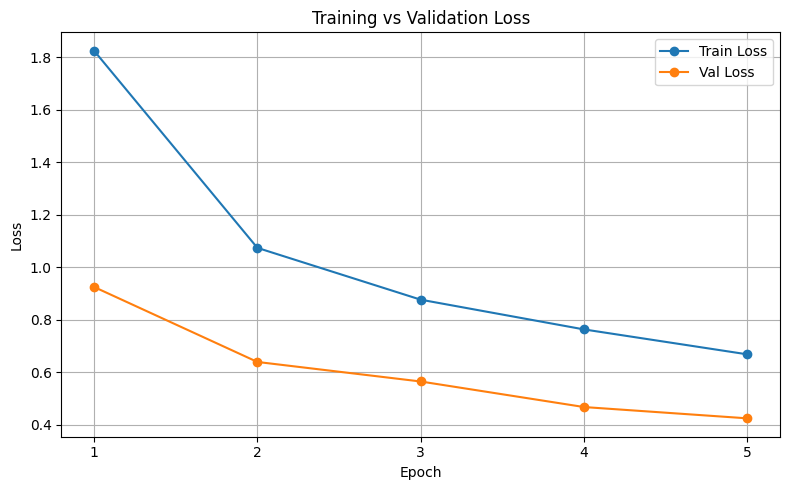

Saved loss_curve.png


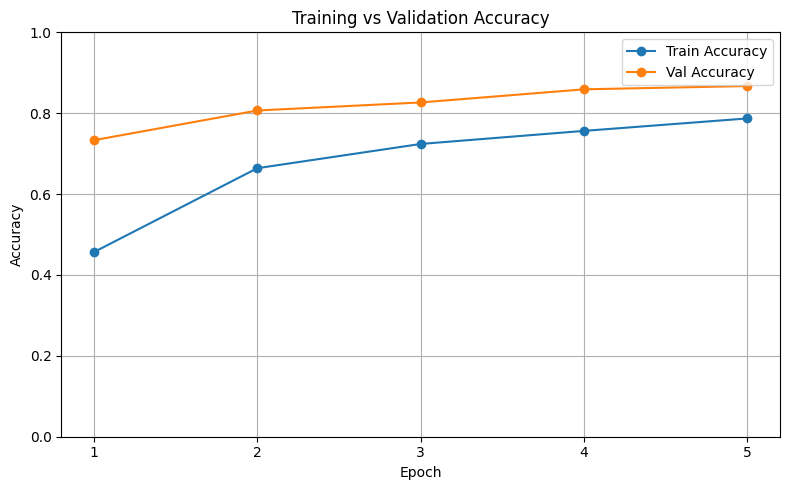

Saved accuracy_curve.png


In [ ]:
import os, json, time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------
# Config
# ------------------------
DATA_DIR = "dataset/Dataset"   # change if your dataset is elsewhere
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5            # increase if you want
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------
# Transforms + DataLoaders
# ------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# base dataset to get classes
base = datasets.ImageFolder(DATA_DIR)
class_names = base.classes
num_classes = len(class_names)
print("Classes (num):", num_classes)
print(class_names)

# split indices 80/20
n = len(base)
n_val = int(0.2 * n)
n_train = n - n_val
train_idx, val_idx = random_split(range(n), [n_train, n_val], generator=torch.Generator().manual_seed(42))

# create datasets with transforms
full_train = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_val   = datasets.ImageFolder(DATA_DIR, transform=val_transform)

train_dataset = torch.utils.data.Subset(full_train, train_idx.indices)
val_dataset   = torch.utils.data.Subset(full_val,   val_idx.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ------------------------
# Model (returns logits)
# ------------------------
class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)    # 224 -> 112
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        # with 3 pools: 224 -> 112 -> 56 -> 28, so flatten dim = 128*28*28
        self.fc1   = nn.Linear(128*28*28, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.drop  = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)          # logits (no softmax)
        return x

model = PlantDiseaseCNN(num_classes).to(device)

# ------------------------
# Loss, Optimizer
# ------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ------------------------
# Storage for metrics
# ------------------------
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
epoch_list = []

best_val_acc = 0.0
start_time = time.time()

# ------------------------
# Training loop
# ------------------------
for epoch in range(1, EPOCHS+1):
    # ---- Train ----
    model.train()
    running_train_loss = 0.0
    train_samples = 0
    train_preds = []
    train_labels = []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)               # logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * imgs.size(0)
        train_samples += imgs.size(0)

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    epoch_train_loss = running_train_loss / train_samples
    epoch_train_acc = accuracy_score(train_labels, train_preds)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0
    val_samples = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * imgs.size(0)
            val_samples += imgs.size(0)

            preds = outputs.argmax(dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    epoch_val_loss = running_val_loss / val_samples
    epoch_val_acc = accuracy_score(val_labels, val_preds)

    # ---- Logging & saving ----
    print(f"[Epoch {epoch}/{EPOCHS}] "
          f"train_loss={epoch_train_loss:.4f}, train_acc={epoch_train_acc:.4f} | "
          f"val_loss={epoch_val_loss:.4f}, val_acc={epoch_val_acc:.4f}")

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    train_acc_history.append(epoch_train_acc)
    val_acc_history.append(epoch_val_acc)
    epoch_list.append(epoch)

    # save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "plant_disease_model_cnn.pth")
        print("  🔥 Saved best CNN: plant_disease_model_cnn.pth")

elapsed = time.time() - start_time
print("Training done — Best val acc: %.4f — Time (s): %.1f" % (best_val_acc, elapsed))

# ------------------------
# Save metrics CSV
# ------------------------
df = pd.DataFrame({
    "epoch": epoch_list,
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "train_acc": train_acc_history,
    "val_acc": val_acc_history
})
df.to_csv("training_metrics.csv", index=False)
print("Saved training_metrics.csv")

# ------------------------
# Plot: Loss curve
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(epoch_list, train_loss_history, marker='o', label='Train Loss')
plt.plot(epoch_list, val_loss_history, marker='o', label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epoch_list)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()
print("Saved loss_curve.png")

# ------------------------
# Plot: Accuracy curve
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(epoch_list, train_acc_history, marker='o', label='Train Accuracy')
plt.plot(epoch_list, val_acc_history, marker='o', label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epoch_list)
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curve.png")
plt.show()
print("Saved accuracy_curve.png")


Device: cuda
Classes: 23 ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Train size: 28580 Val size: 7145
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


[ResNet] Epoch 1/6 | train_loss=0.7417, train_acc=0.8141 | val_loss=0.3516, val_acc=0.8964
  💾 Saved best ResNet checkpoint: plant_disease_model_resnet.pth
[ResNet] Epoch 2/6 | train_loss=0.3411, train_acc=0.8990 | val_loss=0.2452, val_acc=0.9265
  💾 Saved best ResNet checkpoint: plant_disease_model_resnet.pth
🔓 Unfroze entire ResNet for fine-tuning and lowered LR.
[ResNet] Epoch 3/6 | train_loss=0.1668, train_acc=0.9472 | val_loss=0.0751, val_acc=0.9744
  💾 Saved best ResNet checkpoint: plant_disease_model_resnet.pth
[ResNet] Epoch 4/6 | train_loss=0.0766, train_acc=0.9744 | val_loss=0.0431, val_acc=0.9850
  💾 Saved best ResNet checkpoint: plant_disease_model_resnet.pth
[ResNet] Epoch 5/6 | train_loss=0.0654, train_acc=0.9785 | val_loss=0.0426, val_acc=0.9843
[ResNet] Epoch 6/6 | train_loss=0.0464, train_acc=0.9843 | val_loss=0.0613, val_acc=0.9804
ResNet training done. Best val acc: 0.9850244926522044 Elapsed(s): 1385.8047270774841
Saved metrics CSV: training_metrics_resnet.csv


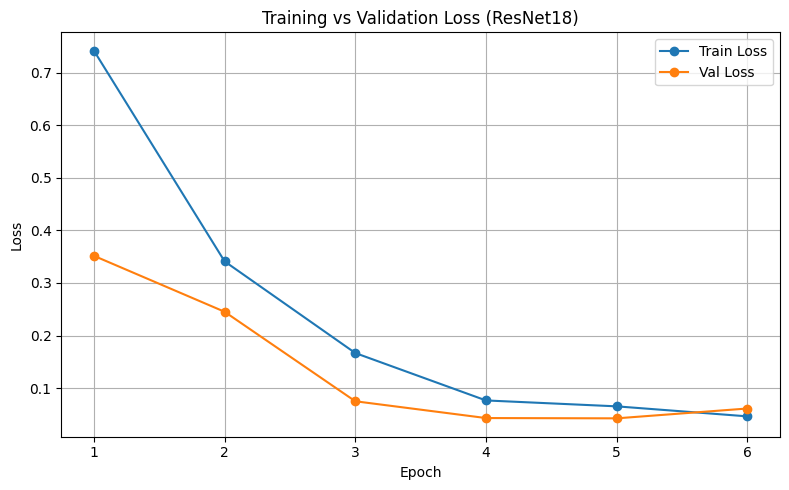

Saved plot: loss_curve_resnet.png


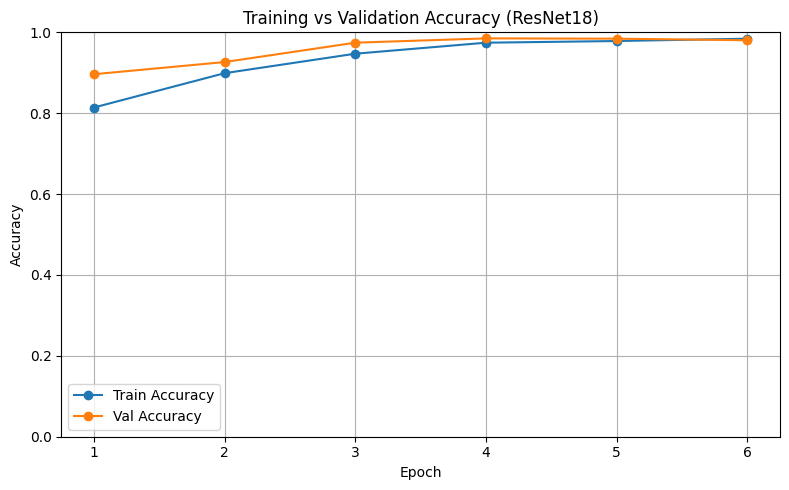

Saved plot: accuracy_curve_resnet.png


In [ ]:
# ResNet training with loss/accuracy curves + CSV (drop-in for your previous cell)
import os, json, time
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score

# ------------------------
# Config
# ------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "dataset/Dataset"
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 6           # you can set 8–12 if you have time
LR_HEAD = 1e-3       # LR for head initially
VAL_SPLIT = 0.2
NUM_WORKERS = 2

print("Device:", DEVICE)

# ------------------------
# Transforms + Dataloaders
# ------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2,0.2,0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# use ImageFolder to detect classes
base = datasets.ImageFolder(DATA_DIR)
class_names = base.classes
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# deterministic 80/20 split
n = len(base)
n_val = int(VAL_SPLIT * n)
n_train = n - n_val
train_idx, val_idx = random_split(range(n), [n_train, n_val], generator=torch.Generator().manual_seed(42))

full_train = datasets.ImageFolder(DATA_DIR, transform=train_transform)
full_val   = datasets.ImageFolder(DATA_DIR, transform=val_transform)

train_dataset = torch.utils.data.Subset(full_train, train_idx.indices)
val_dataset   = torch.utils.data.Subset(full_val,   val_idx.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train size:", len(train_dataset), "Val size:", len(val_dataset))

# ------------------------
# Model setup (ResNet18)
# ------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)

# freeze backbone except final fc initially
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)

# ------------------------
# Metric storage
# ------------------------
epoch_nums = []
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0
start_time = time.time()

# ------------------------
# Training loop
# ------------------------
for epoch in range(1, EPOCHS + 1):
    # unfreeze backbone for fine-tuning at epoch 3 (as before)
    if epoch == 3:
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=LR_HEAD * 0.2)
        print("🔓 Unfroze entire ResNet for fine-tuning and lowered LR.")

    # ---- training pass ----
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    total_samples = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)           # logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        total_samples += imgs.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = accuracy_score(all_labels, all_preds)

    # ---- validation pass ----
    model.eval()
    v_running_loss = 0.0
    v_preds = []
    v_labels = []
    v_samples = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            v_running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            v_preds.extend(preds.cpu().numpy())
            v_labels.extend(labels.cpu().numpy())
            v_samples += imgs.size(0)

    epoch_val_loss = v_running_loss / v_samples
    epoch_val_acc = accuracy_score(v_labels, v_preds)

    # ---- logging ----
    print(f"[ResNet] Epoch {epoch}/{EPOCHS} | "
          f"train_loss={epoch_train_loss:.4f}, train_acc={epoch_train_acc:.4f} | "
          f"val_loss={epoch_val_loss:.4f}, val_acc={epoch_val_acc:.4f}")

    epoch_nums.append(epoch)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    # save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "plant_disease_model_resnet.pth")
        print("  💾 Saved best ResNet checkpoint: plant_disease_model_resnet.pth")

# ------------------------
# Done
# ------------------------
elapsed = time.time() - start_time
print("ResNet training done. Best val acc:", best_val_acc, "Elapsed(s):", elapsed)

# save class names (useful later for inference)
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

# save numeric metrics CSV
df = pd.DataFrame({
    "epoch": epoch_nums,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs
})
csv_fname = "training_metrics_resnet.csv"
df.to_csv(csv_fname, index=False)
print("Saved metrics CSV:", csv_fname)

# ------------------------
# Plot Loss Curve
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(epoch_nums, train_losses, marker='o', label='Train Loss')
plt.plot(epoch_nums, val_losses, marker='o', label='Val Loss')
plt.title('Training vs Validation Loss (ResNet18)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epoch_nums)
plt.grid(True)
plt.legend()
plt.tight_layout()
loss_png = "loss_curve_resnet.png"
plt.savefig(loss_png)
plt.show()
print("Saved plot:", loss_png)

# ------------------------
# Plot Accuracy Curve
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(epoch_nums, train_accs, marker='o', label='Train Accuracy')
plt.plot(epoch_nums, val_accs, marker='o', label='Val Accuracy')
plt.title('Training vs Validation Accuracy (ResNet18)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epoch_nums)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
acc_png = "accuracy_curve_resnet.png"
plt.savefig(acc_png)
plt.show()
print("Saved plot:", acc_png)


In [ ]:
%%writefile app_cnn.py
from flask import Flask, render_template, request
from PIL import Image
import torch, torch.nn as nn
from torchvision import transforms
import os, json, cv2

app = Flask(__name__)
UPLOAD_FOLDER = "static/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

@app.route("/health")
def health():
    return "OK", 200

@app.route("/plain_debug")
def plain_debug():
    return "<html><body><h1>DEBUG PAGE</h1><p>If you see this, Flask is serving HTML.</p></body></html>"

# classes
with open("class_names.json","r") as f:
    classes = json.load(f)
num_classes = len(classes)

class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1   = nn.Linear(128*28*28, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.drop  = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return torch.softmax(x, dim=1)

model = PlantDiseaseCNN(num_classes)
model.load_state_dict(torch.load("plant_disease_model_cnn.pth", map_location="cpu"))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def estimate_severity(path):
    img = cv2.imread(path)
    if img is None:
        return 0.0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)
    infected = cv2.countNonZero(mask)
    total = mask.size
    return round((infected/total)*100,2) if total>0 else 0.0

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files.get("file")
    if not file:
        return render_template("index.html", error="Please upload an image.")
    filename = file.filename
    path = os.path.join(UPLOAD_FOLDER, filename)
    file.save(path)

    img = Image.open(path).convert("RGB")
    img_t = transform(img).unsqueeze(0)

    with torch.no_grad():
        out = model(img_t)
        prob, pred = torch.max(out, 1)

    prediction = classes[pred.item()]
    confidence = round(float(prob.item())*100, 2)
    severity = estimate_severity(path)

    return render_template("index.html",
                           prediction=prediction,
                           confidence=confidence,
                           severity=severity,
                           image_path=path)

if __name__ == "__main__":
    app.run(port=5000)


Writing app_cnn.py


In [ ]:
#app.py for resNet18
%%writefile app.py
from flask import Flask, render_template, request
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms, models
import os, json, cv2

app = Flask(__name__)
UPLOAD_FOLDER = "static/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# ---------- Utility routes ----------
@app.route("/health")
def health():
    return "OK", 200

@app.route("/plain_debug")
def plain_debug():
    return "<html><body><h1>DEBUG PAGE</h1><p>If you see this, Flask is serving HTML.</p></body></html>"

# ---------- Load classes ----------
with open("class_names.json", "r") as f:
    classes = json.load(f)
num_classes = len(classes)

# ---------- Disease info (yield + solution) ----------
# NOTE: Values are rough, for academic/demo purposes only.
DISEASE_INFO = {
    "Apple___Apple_scab": {
        "yield_rate": "50–70% (moderate to high loss)",
        "solution": (
            "Prune and destroy infected leaves/twigs, improve air circulation, "
            "avoid overhead irrigation, and spray protectant fungicides "
            "(e.g., captan, mancozeb) according to local guidelines."
        ),
    },
    "Apple___Black_rot": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Remove mummified fruits and cankered branches, sanitize orchard floor, "
            "and apply recommended fungicides at early fruit development stages."
        ),
    },
    "Apple___Cedar_apple_rust": {
        "yield_rate": "70–85% (low to moderate loss)",
        "solution": (
            "Remove nearby cedar hosts if possible, prune infected tissue, "
            "and use rust-specific fungicides at pink and bloom stages."
        ),
    },
    "Apple___healthy": {
        "yield_rate": "95–100% (no significant loss)",
        "solution": "Maintain proper irrigation, fertilization, and regular scouting to keep trees healthy.",
    },
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Use resistant hybrids, rotate with non-host crops, avoid dense planting, "
            "and apply foliar fungicides at VT–R1 if disease pressure is high."
        ),
    },
    "Corn_(maize)___Common_rust_": {
        "yield_rate": "75–90% (usually low loss with control)",
        "solution": (
            "Plant resistant hybrids and, if severe before tasselling, "
            "consider fungicide application as per local recommendations."
        ),
    },
    "Corn_(maize)___Northern_Leaf_Blight": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Use resistant varieties, rotate crops, bury crop residues, "
            "and apply foliar fungicides when lesions first appear on upper leaves."
        ),
    },
    "Corn_(maize)___healthy": {
        "yield_rate": "95–100% (no significant loss)",
        "solution": "Continue good nutrient management, weed control, and regular monitoring.",
    },
    "Pepper__bell___Bacterial_spot": {
        "yield_rate": "50–75% (moderate to high loss)",
        "solution": (
            "Use certified disease-free seed or seedlings, avoid working in wet foliage, "
            "remove infected plants, and apply copper-based bactericides as per label."
        ),
    },
    "Pepper__bell___healthy": {
        "yield_rate": "95–100% (no significant loss)",
        "solution": "Maintain balanced fertilization and irrigation; monitor for early disease symptoms.",
    },
    "Potato___Early_blight": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Use resistant cultivars, avoid water stress, remove infected debris, "
            "and spray protective fungicides (chlorothalonil, mancozeb) on a schedule."
        ),
    },
    "Potato___Late_blight": {
        "yield_rate": "30–60% (very high loss if unmanaged)",
        "solution": (
            "Use certified seed, destroy volunteer potatoes, avoid overhead irrigation, "
            "and follow a strict fungicide spray program at first sign or favorable weather."
        ),
    },
    "Potato___healthy": {
        "yield_rate": "95–100% (no significant loss)",
        "solution": "Maintain hilling, good drainage, and regular scouting for late blight and other diseases.",
    },
    "Tomato_Bacterial_spot": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Use disease-free seed/transplants, avoid overhead irrigation, "
            "remove infected leaves, and apply copper-based bactericides."
        ),
    },
    "Tomato_Early_blight": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Mulch around plants, remove lower infected leaves, rotate crops, "
            "and use protectant fungicides like chlorothalonil or mancozeb."
        ),
    },
    "Tomato_Late_blight": {
        "yield_rate": "30–60% (very high loss if unmanaged)",
        "solution": (
            "Use resistant varieties, destroy infected plants immediately, "
            "avoid overhead watering, and apply systemic + protectant fungicides frequently."
        ),
    },
    "Tomato_Leaf_Mold": {
        "yield_rate": "70–85% (low to moderate loss)",
        "solution": (
            "Improve greenhouse or field ventilation, avoid prolonged leaf wetness, "
            "remove infected leaves, and apply suitable fungicides if needed."
        ),
    },
    "Tomato_Septoria_leaf_spot": {
        "yield_rate": "65–85% (moderate loss)",
        "solution": (
            "Remove lower diseased leaves, avoid overhead irrigation, "
            "rotate away from solanaceous crops, and use protectant fungicides."
        ),
    },
    "Tomato_Spider_mites_Two_spotted_spider_mite": {
        "yield_rate": "70–90% (can be high under heavy infestation)",
        "solution": (
            "Increase humidity slightly, use miticides or insecticidal soap, "
            "and encourage natural predators like lady beetles and predatory mites."
        ),
    },
    "Tomato__Target_Spot": {
        "yield_rate": "60–80% (moderate loss)",
        "solution": (
            "Remove infected foliage, avoid water splash, rotate crops, "
            "and apply recommended fungicides when spots first appear."
        ),
    },
    "Tomato__Tomato_YellowLeaf__Curl_Virus": {
        "yield_rate": "20–60% (very high loss, virus disease)",
        "solution": (
            "Control whitefly vectors with insecticides or nets, use virus-tolerant varieties, "
            "remove and destroy infected plants immediately."
        ),
    },
    "Tomato__Tomato_mosaic_virus": {
        "yield_rate": "50–80% (high loss, virus disease)",
        "solution": (
            "Use resistant varieties, disinfect tools and hands, avoid smoking near plants, "
            "and remove infected plants to limit spread."
        ),
    },
    "Tomato_healthy": {
        "yield_rate": "95–100% (no significant loss)",
        "solution": "Maintain staking, pruning, balanced nutrition, and regular scouting.",
    },
}

DEFAULT_INFO = {
    "yield_rate": "Not available",
    "solution": "Follow good agronomic practices and consult local experts for precise management."
}

# ---------- Model (ResNet18) ----------
model = models.resnet18(weights=None)
in_f = model.fc.in_features
model.fc = nn.Linear(in_f, num_classes)
model.load_state_dict(torch.load("plant_disease_model_resnet.pth", map_location="cpu"))
model.eval()

# transforms (MUST match training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ---------- Severity estimation ----------
def estimate_severity(path):
    img = cv2.imread(path)
    if img is None:
        return 0.0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, mask = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY_INV)
    infected = cv2.countNonZero(mask)
    total = mask.size
    if total == 0:
        return 0.0
    return round((infected / total) * 100, 2)

# ---------- Routes ----------
@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files.get("file")
    if not file:
        return render_template("index.html", error="Please upload an image.")

    filename = file.filename
    save_path = os.path.join(UPLOAD_FOLDER, filename)
    file.save(save_path)

    # preprocess
    img = Image.open(save_path).convert("RGB")
    img_t = transform(img).unsqueeze(0)

    with torch.no_grad():
        out = model(img_t)
        prob, pred_idx = torch.max(out, 1)

    prediction = classes[pred_idx.item()]
    confidence = round(float(prob.item()) * 100, 2)
    severity = estimate_severity(save_path)

    info = DISEASE_INFO.get(prediction, DEFAULT_INFO)

    return render_template(
        "index.html",
        prediction=prediction,
        confidence=confidence,
        severity=severity,
        yield_rate=info["yield_rate"],
        solution=info["solution"],
        image_path=save_path
    )

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)


Writing app.py


In [ ]:
# Write template + css (run in notebook)
import os
os.makedirs("templates", exist_ok=True)

html = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Plant Disease Detector</title>
  <link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}">
</head>
<body>
  <div class="container">
    <h1>Plant Disease Detection Web Application</h1>
    <form method="POST" action="/predict" enctype="multipart/form-data">
      <input type="file" name="file" accept="image/*" required>
      <button type="submit">Predict Disease</button>
    </form>

    {% if image_path %}
      <div class="result">
        <h2>Result</h2>
        <img src="{{ url_for('static', filename='uploads/' + image_path.split('/')[-1]) }}" width="300">
        <p><b>Prediction:</b> {{ prediction }}</p>
        <p><b>Confidence:</b> {{ confidence }}%</p>
        <p><b>Severity:</b> {{ severity }}%</p>
        <p><b>Crop Yield Rate (approx):</b> {{ yield_rate }}</p>
        <p><b>Recommended Solution:</b> {{ solution }}</p>
      </div>
    {% endif %}

    {% if error %}
      <p style="color:red;">{{ error }}</p>
    {% endif %}
  </div>
</body>
</html>
"""

with open("templates/index.html","w") as f:
    f.write(html)

css = """
body {
  font-family: Arial, sans-serif;
  background-color: #eef6ee;
  text-align: center;
  padding: 20px;
}
.container {
  background: white;
  border-radius: 20px;
  padding: 30px;
  width: 70%;
  margin: auto;
  box-shadow: 0 0 10px rgba(0,0,0,0.1);
}
button {
  background-color: #4CAF50;
  color: white;
  padding: 10px 20px;
  border: none;
  border-radius: 8px;
  cursor: pointer;
}
button:hover {
  background-color: #45a049;
}
.result { margin-top: 30px; }
"""
with open("static/style.css","w") as f:
    f.write(css)
print("Wrote templates/index.html and static/style.css")


Wrote templates/index.html and static/style.css


In [ ]:
# Linux install (Debian/Ubuntu)
!curl -L -o cloudflared.deb https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!apt-get update -qq
!apt-get install -qq ./cloudflared.deb


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.4M  100 18.4M    0     0  17.6M      0  0:00:01  0:00:01 --:--:-- 93.1M
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package cloudflared.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack /content/cloudflared.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!wget -N https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64


--2026-03-22 04:23:47--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-22 04:23:47--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-22T05%3A21%3A48Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-22T0

In [ ]:
import os
os.listdir()


['.config',
 'cloudflared.deb',
 'class_names.json',
 'training_metrics.csv',
 'loss_curve_resnet.png',
 '.ipynb_checkpoints',
 'plant_disease_model_resnet.pth',
 'loss_curve.png',
 'accuracy_curve_resnet.png',
 'plant_disease_model_cnn.pth',
 'templates',
 'app_cnn.py',
 'app.py',
 'dataset',
 'accuracy_curve.png',
 'cloudflared-linux-amd64',
 'PDD dataset.zip',
 'training_metrics_resnet.csv',
 'static',
 'sample_data']

In [ ]:
# start Flask in background thread (Python cell)
import threading, time, requests, importlib
import app
importlib.reload(app)

def run_app():
    app.app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)

t = threading.Thread(target=run_app, daemon=True)
t.start()
print("Started Flask in background...")

# wait until local ready
for i in range(40):
    try:
        r = requests.get("http://127.0.0.1:5000/health", timeout=1)
        if r.status_code == 200:
            print("Local Flask OK")
            break
    except Exception:
        time.sleep(0.25)
else:
    raise RuntimeError("Flask not responding on port 5000")


Started Flask in background...
 * Serving Flask app 'app'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:23:55] "GET /health HTTP/1.1" 200 -


Local Flask OK


In [ ]:
# Run cloudflared (exposes an ephemeral url)
# This assumes cloudflared is installed and available in PATH
!cloudflared tunnel --url http://127.0.0.1:5000 --no-autoupdate


2026-03-22T04:24:01Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-22T04:24:01Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-22T04:24:03Z INF +--------------------------------------------------------------------------------------------+
2026-03-22T04:24:03Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-22T04:24:03Z INF |  https://dude-ride-operation-felt.trycloudflare.com   

INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:07] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:07] "GET /static/style.css HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:08] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:21] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:21] "GET /static/uploads/appleD.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:25:21] "GET /static/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:26:19] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:26:19] "GET /static/uploads/apple%20H.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:26:19] "GET /static/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:26:52] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Mar/2026 04:26:52] "GET /static/uploads/corn%20plant.jpg HTTP/1.1" 200 -
INFO:werkzeug:127.0